# 2o Lab de PSD (notebook para preencher com os resultados)

In [ ]:
#
# Importa os pacotes necessários
#
import numpy as np
import matplotlib.pyplot as plt

## Correlação cruzada

A amplitude de cada ponto no sinal da correlação cruzada é uma medida de similaridade entre os entre os sinais de entrada nesse ponto. A correlação é uma ótima técnica para detectar um sinal conhecido dentro de um outro sinal, mesmo na presença de ruído.

# PROBLEMA 1
Dada uma imagem $f$ e um filtro $w$ de dimensões $(2a+1)\times (2b+1)$, então a correlação-cruzada da imagem $f$ com o filtro $w$ é calculada pela fórmula
\begin{equation}
g(x,y)=\sum_{s=0}^{2a}\sum_{t=0}^{2b}w(s,t)f(x+s-a, y+t-b)
\end{equation}

LEMBRETE:

Uma imagem $f$ é representada como uma matriz (array bidimensional) e, no caso do python, é comum armazenarmos os pixels da imagem numa estrutura __numpy.array__

$x$ e $y$ correspondem aos índices da linha e coluna da imagem que está sendo analisada

$s$ e $t$ correspondem aos índices da linha e coluna do filtro

$a$ e $b$ são números inteiros maiores ou iguais a 1. Em geral, $a=b$

## Parte a - preencha as partes faltantes do código abaixo

OBS: Leia com **muita atenção** os comentários presentes no código

In [ ]:
#
# Escrever uma função que faça o zero-padding de uma imagem f
#
# Parâmetros
#    f : numpy array. Imagem para fazer o zero-padding.
#    ps_rows: quantidade de linhas extras da matriz imagem (2*a)
#    ps_cols: quantidade de colunas extras da matriz imagem (2*b)
#
# Saída:
#    f_padded : numpy array. Image após o zero-padding

def zero_padding(f, ps_rows, ps_cols):
    #
    # Obtenha as informações do tamanho de f
    #
    # -> INCLUIR SEU CÓDIGO AQUI
    len_row_f, len_col_f = f.shape

    a = ps_rows // 2
    b = ps_cols // 2

    #
    # Crie a matriz de tamanho ajustado (f_padded) que receberá a imagem original
    #

    # Sugestão: utilize a função np.zeros para criar uma imagem temporária para
    # armazenar a imagem com o padding de zeros
    #
    # -> INCLUIR SEU CÓDIGO AQUI
    f_padded = np.zeros((len_row_f + ps_rows, len_col_f + ps_cols))

    #
    # Copie de maneira apropriada os pixels da imagem f na imagem zero-padded temporária
    #

    # Você pode usar loops ou não (a maneira mais eficiente é sem loops - procure sobre "Broadcasting" em python)
    #

    # -> INCLUIR SEU CÓDIGO AQUI
    f_padded[a : a + len_row_f, b : b + len_col_f] = f

    return f_padded

f = np.array([[1,2],[3,4]])
a = 2
b = 2
new_f = zero_padding(f, a, b)
print("Verificando se a adição do padding funcionou corretamente:")
print(f)
print("Após a adição do padding:")
print(new_f)

Verificando se a adição do padding funcionou corretamente:
[[1 2]
 [3 4]]
Após a adição do padding:
[[0. 0. 0. 0.]
 [0. 1. 2. 0.]
 [0. 3. 4. 0.]
 [0. 0. 0. 0.]]


In [ ]:
#
# Calcula a correlação cruzada entre a imagem f e o filtro w
#
# Parâmetros
#    f : numpy array. Imagem a ser filtrada.
#    w : numpy array. Filtro a ser utilizado na correlação cruzada
#
# Saída:
#    f_filtered : numpy array. Image filtrada de mesmo tamanho que a imagem de entrada
#
def correlation(f, w):
    #
    # Obtendo informações das dimensões de f e w
    #
    f_rows, f_cols = f.shape
    w_rows, w_cols = w.shape   # w_rows = 2*a+1 e w_cols = 2*b+1 (a e b na fórmula acima)

    a = (w_rows-1)//2          # O operador "//" retorna a parte inteira da divisão
    b = (w_cols-1)//2

    #
    # Usando as informações acima e a função padding criada anteriormente, crie uma imagem de nome "f_padded" (de mesmo tipo da imagem de entrada)
    # que correspondem à imagem de entrada "f" com zeros em suas bordas - "zero padding"
    #
    # -> INCLUIR SEU CÓDIGO AQUI
    f_padded = zero_padding(f, 2*a, 2*b)

    # Crie uma imagem de saída (f_filtered) com pixels de valor zero
    # -> INCLUIR SEU CÓDIGO AQUI
    f_filtered = np.zeros((f_rows, f_cols))

    #
    # Implementar os loops aninhados necessários para a implementação da fórmula de correlação
    #

    # DICA: Loops externos -> percorrerm pixels da imagem; Loops internos -> percorrem coeficientes do filtro
    #
    # -> INCLUIR SEU CÓDIGO AQUI
    for x in range (f_rows):
      for y in range (f_cols):
        for s in range (2 * a + 1):
          for t in range (2 * b + 1):
            f_filtered[x, y] += w[s, t] * f_padded[x + s, y + t]

    return f_filtered

In [ ]:
#
# Calcula a convolução entre a imagem img e o filtro w
#
# Parâmetros de entrada:
#    img : numpy array. Imagem a ser filtrada.
#    w   : numpy array. Filtro a ser utilizado na correlação cruzada
#
# Saída:
#    img_filtered : numpy array. Image filtrada de mesmo tamanho que a imagem de entrada
#
def convolution(img, w):
    invert_w = np.flip(w)

    # -> INCLUIR SEU CÓDIGO AQUI
    img_filtered = correlation(img, invert_w)

    return img_filtered

## Teste do código: Correlação entre sinal e filtro 1D

In [ ]:
# Sinal artificial 1D. Como a função acima foi implementada para arrays 2D,
# nosso sinal 1D será representado por uma matriz de uma única linha
sinal = np.array([[2, 3, 1, 4, 3, 2, 1, 1, 2]])

# filtro
w = np.array([[1, 2, 3]])

# chamada da função criada anteriormente
sinal_filtered = correlation(sinal, w)

# imprime resultado.
print(sinal_filtered)
print(f'Sinal esperado: [[13. 11. 17. 18. 16. 10.  7.  9.  5.]]')

#
# O resultado deve gerar a seguinte sequência [[13. 11. 17. 18. 16. 10.  7.  9.  5.]]
#

[[13. 11. 17. 18. 16. 10.  7.  9.  5.]]
Sinal esperado: [[13. 11. 17. 18. 16. 10.  7.  9.  5.]]


## Teste do código: Comparação entre correlação e convolução

In [ ]:
#
# Analise o código abaixo com muita atenção
#

img = np.array([[0, 0, 0, 0, 1, 0, 0, 0, 0]])
w = np.array([[1, 2, 3, 4, 5]])

# Teste da propriedade comutativa da correlação
img_corr_w = correlation(img, w)
w_corr_img = correlation(w, img)

print(f'img_corr_w: {img_corr_w}')
print(f'Esperado img_corr_w: [[0 0 5 4 3 2 1 0 0]]\n')

print(f'w_corr_img: {w_corr_img}')
print(f'Esperado w_corr_img: [[1 2 3 4 5]]\n')

# Teste da propriedade comutativa da convolução
img_conv_w = convolution(img, w)
w_conv_img = convolution(w, img)

print(f'img_conv_w: {img_conv_w}')
print(f'Esperado img_conv_w: [[0 0 1 2 3 4 5 0 0]]\n')

print(f'w_conv_img: {w_conv_img}')
print(f'Esperado w_conv_img: [[1 2 3 4 5]]\n')

#
# O código dever gerar a seguinte saída
#
# img_corr_w:
# [[0 0 5 4 3 2 1 0 0]]
# w_corr_img:
# [[1 2 3 4 5]]

# img_conv_w:
# [[0 0 1 2 3 4 5 0 0]]
# w_conv_img:
# [[1 2 3 4 5]]

img_corr_w: [[0. 0. 5. 4. 3. 2. 1. 0. 0.]]
Esperado img_corr_w: [[0 0 5 4 3 2 1 0 0]]

w_corr_img: [[1. 2. 3. 4. 5.]]
Esperado w_corr_img: [[1 2 3 4 5]]

img_conv_w: [[0. 0. 1. 2. 3. 4. 5. 0. 0.]]
Esperado img_conv_w: [[0 0 1 2 3 4 5 0 0]]

w_conv_img: [[1. 2. 3. 4. 5.]]
Esperado w_conv_img: [[1 2 3 4 5]]



## Parte b - filtro da média simples aplicado a uma imagem

<class 'numpy.ndarray'>


Text(0.5, 1.0, 'Imagem Filtrada - 7x7')

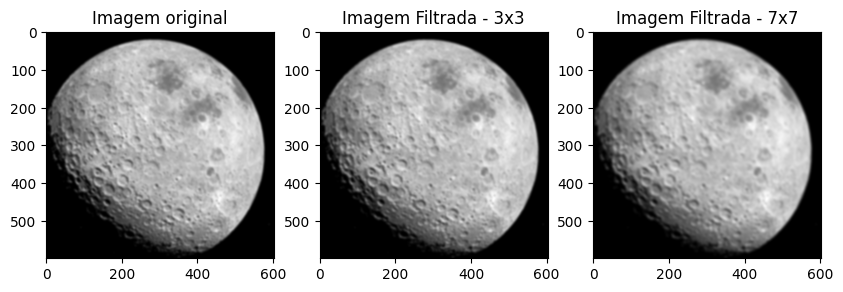

In [ ]:
#
# Leitura de uma imagem - https://www.geeksforgeeks.org/python-opencv-cv2-imread-method/
#
# Note que a função imread retorna um "numpy array" que representa a imagem ou "None"
# se a imagem não puder ser carregada.
#
import cv2
# img = cv2.imread("cameraman.tiff", cv2.IMREAD_GRAYSCALE)
img = cv2.imread("moon.tiff", cv2.IMREAD_GRAYSCALE)
print(type(img))

#
# Visualiza a imagem original
# DICA: https://www.geeksforgeeks.org/how-to-display-multiple-images-in-one-figure-correctly-in-matplotlib/
#

# create figure
fig = plt.figure(figsize=(10, 7))

# Adds a subplot at the 1st position
fig.add_subplot(1, 3, 1)

# showing original image
plt.imshow(img, cmap = 'gray', interpolation = 'bicubic')
plt.title("Imagem original")

# --------------------------------------------------------------------
# Defina um "box filter" do tipo matrix "numpy array" de tamanho 3x3
# --------------------------------------------------------------------

# -> INCLUIR SEU CÓDIGO AQUI
# Filtro que calcula a média dos valores dos pixels dentro da janela, matriz 3x3 com valores 1
box_filter = np.ones((3, 3)) / 9

#
# Chama função de correlação
#
img_filtered = correlation(img, box_filter)

# Adds a subplot at the 1st position
fig.add_subplot(1, 3, 2)

# showing filtered image
plt.imshow(img_filtered, cmap = 'gray', interpolation = 'bicubic')
plt.title("Imagem Filtrada - 3x3")


# --------------------------------------------------------------------
# Defina um "box filter" do tipo matrix "numpy array" de tamanho 7x7
# --------------------------------------------------------------------

# -> INCLUIR SEU CÓDIGO AQUI
# Filtro que calcula a média dos valores dos pixels dentro da janela, matriz 3x3 com valores 1
box_filter2 = np.ones((7,7)) / 49

#
# Chama função de correlação
#
img_filtered = correlation(img, box_filter2)

# Adds a subplot at the 1st position
fig.add_subplot(1, 3, 3)

# showing filtered image
plt.imshow(img_filtered, cmap = 'gray', interpolation = 'bicubic')
plt.title("Imagem Filtrada - 7x7")

## PROBLEMA 2

**Template Matching** é uma técnica comumente utilizada em Visão Computacional para localizar uma "imagem template" $w$ dentro de uma outra imagem $f$. Essa técnica é **implementada** usando a operação de correlação cruzada (**cross-correlation**) normalizada, que é calculada usando a seguinte equação:

\begin{equation}
N_{tf}[x,y]=\frac{\sum_{s=0}^{2a}\sum_{t=0}^{2b}f(x+s-a, y+t-b)\: w(s,t)}{\sqrt{\sum_{s=0}^{2a}\sum_{t=0}^{2b}f^2(x+s-a, y+t-b)}\: \sqrt{\sum_{s=0}^{2a}\sum_{t=0}^{2b}w^2(s,t)}}
\end{equation}


## Parte a - estude o código abaixo, analisando como a correlação cruzada foi implementada

In [ ]:
#
# Normalised Cross Correlation
#
def Normalised_Cross_Correlation(roi, target):
    # Normalised Cross Correlation Equation
    cor = np.sum(roi * target)
    nor = np.sqrt( (np.sum(roi ** 2))) * np.sqrt(np.sum(target ** 2))

    return cor / nor

In [ ]:
#
# Template Matching
#
def template_matching(img, target):
    # initial parameter
    height, width = img.shape
    tar_height, tar_width = target.shape
    (max_Y, max_X) = (0, 0)
    MaxValue = 0

    # Set image, target and result value matrix
    img = np.array(img, dtype="int")
    target = np.array(target, dtype="int")
    NccValue = np.zeros((height-tar_height, width-tar_width))

    # calculate value using a filter-kind operation from top-left to bottom-right
    for y in range(0, height-tar_height):
        for x in range(0, width-tar_width):
            # get image roi
            roi = img[y : y+tar_height, x : x+tar_width]

            # calculate ncc value
            NccValue[y, x] = Normalised_Cross_Correlation(roi, target)
            print(NccValue[y,x])

            # find the most match area
            if NccValue[y, x] > MaxValue:
                MaxValue = NccValue[y, x]
                (max_Y, max_X) = (y, x)

    return (max_X, max_Y)

# Teste
f = np.array([
    [1, 2, 3, 0, 1],
    [4, 5, 6, 1, 0],
    [7, 8, 9, 2, 1],
    [1, 3, 5, 2, 0],
    [0, 1, 4, 1, 2]
])

w = np.array([
    [1, 0, -1],
    [1, 0, -1],
    [1, 0, -1]
])

print(template_matching(f, w))

-0.14509525002200233
0.3273268353539886
-0.18670401120373467
0.2845885260923221
(1, 0)


## Parte b - Reescreva o código acima seguindo rigorosamente a equação da correlação cruzada

In [ ]:
#
# Inserir o seu código abaixo
#
def normalized_crosscorrelation(img, w):
    img_height, img_width = img.shape
    w_height, w_width = w.shape
    (max_Y, max_X) = (0, 0)

    # fazer correlação para cada parcela do dado (que tem o tamanho do filtro)

    # Criando as matrizes da imagem, do filtro e do resultado da correlação
    img = np.array(img)
    w = np.array(w)

    height = img_height - w_height
    width = img_width - w_width
    crosscorr = np.zeros((height, width))

    max_corr = -999

    for y in range(0, height):
      for x in range(0, width):
        # A correlação é realizada em cada parcela com tamanho igual ao filtro
        roi = img[y : y + w_height, x : x + w_width]

        # Correlação
        numerator = np.sum(roi * w)
        denominator = np.sqrt((np.sum(roi ** 2))) * np.sqrt(np.sum(w ** 2))
        crosscorr[y, x] = numerator / denominator


        # Buscando o maior na matriz de correlação
        if crosscorr[y, x] > max_corr:
          (max_Y, max_X) = y, x
          max_corr = crosscorr[y, x]

    return (max_X, max_Y)

# Teste
f = np.array([
    [1, 2, 3, 0, 1],
    [4, 5, 6, 1, 0],
    [7, 8, 9, 2, 1],
    [1, 3, 5, 2, 0],
    [0, 1, 4, 1, 2]
])

w = np.array([
    [1, 0, -1],
    [1, 0, -1],
    [1, 0, -1]
])

print(normalized_crosscorrelation(f, w))


(1, 0)


## Parte c - Template Matching usando OpenCV

Usando a função **cv.matchTemplate** do pacote opencv (https://docs.opencv.org/3.4/de/da9/tutorial_template_matching.html), crie um programa que faça o mesmo que o código acima.

OBS: Analise o resultado de cada uma das __6 variações__ do Template Matching disponíveis no OpenCV.

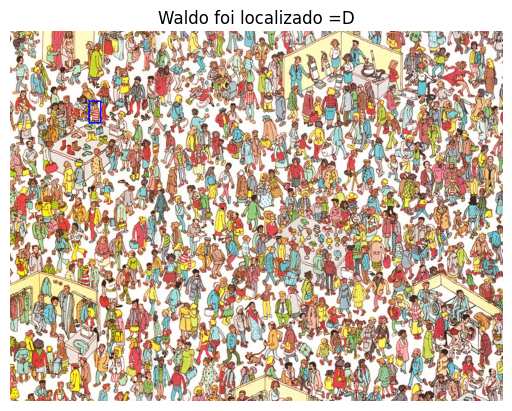

In [ ]:
#
# Template Matching using opencv
#

#
# Leitura das imagens
#
image = cv2.imread("where_is_Waldo.jpg")
imageGray  = cv2.imread("where_is_Waldo.jpg", cv2.IMREAD_GRAYSCALE)
templateGray = cv2.imread("Waldo_picture.png", cv2.IMREAD_GRAYSCALE)

#
# Estudo os códigos em opencv do link acima e determine usando a função
# cv2.matchTemplate para determinar a posição do Waldo e também a
# função cv2.rectangle para indicar localização do Waldo na imagem original
#

# -> INCLUIR SEU CÓDIGO AQUI
tem_len_h, tem_len_w = templateGray.shape

# Aplicando a correlação cruzada normalizada
result = cv2.matchTemplate(imageGray, templateGray, cv2.TM_CCORR_NORMED)

# Posição do Waldo
a, b, c, d = cv2.minMaxLoc(result)

# Top-left da área encontrada
top_left = d

# Bottom-right com base no tamanho da imagem do Waldo
bottom_right = (top_left[0] + tem_len_w, top_left[1] + tem_len_h)

# Indicando a localização do Waldo na imagem original
cv2.rectangle(image, top_left, bottom_right, (255, 0, 0), 2)

# Mostrando imagem nas cores corretas
imageRGB = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Exibe a imagem com a marcação
plt.imshow(imageRGB)
plt.title("Waldo foi localizado =D")
plt.axis('off')
plt.show()

## Descreva de maneira sucinta nesta célula os resultados obtidos das variações do Template Matching do OpenCV


Link de aula de visão computacional sobre tracking de objetos em vídeo - https://youtu.be/2wwVogo88aY

In [ ]:
'''
Pode-se observar, comparando o template matching feito seguindo a fórmula da
convolução cruzada normalizada e feito mediante as funções do OpenCV, que
o OpenCV fornece uma abordagem muito mais sucinta e eficiente na implementação
do template matching. Esse é um grande benefício desse pacote, pois facilita e
otimiza bastante o uso de conceitos como a própria correlação cruzada normalizada
em aplicaões de visão computacional, sobretudo, quando o objetivo não é realizar
implementações do zero, e sim usufruir dos seus resultados.
 '''